# Ebay Customers Life Time Value 

In [1]:
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter, plotting
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, plot_period_transactions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
import pandas as pd
import lifetimes

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [2]:
df = pd.read_csv('Ebay.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [3]:
max(df['Quantity'])

80995

# Data Visulization and EDA

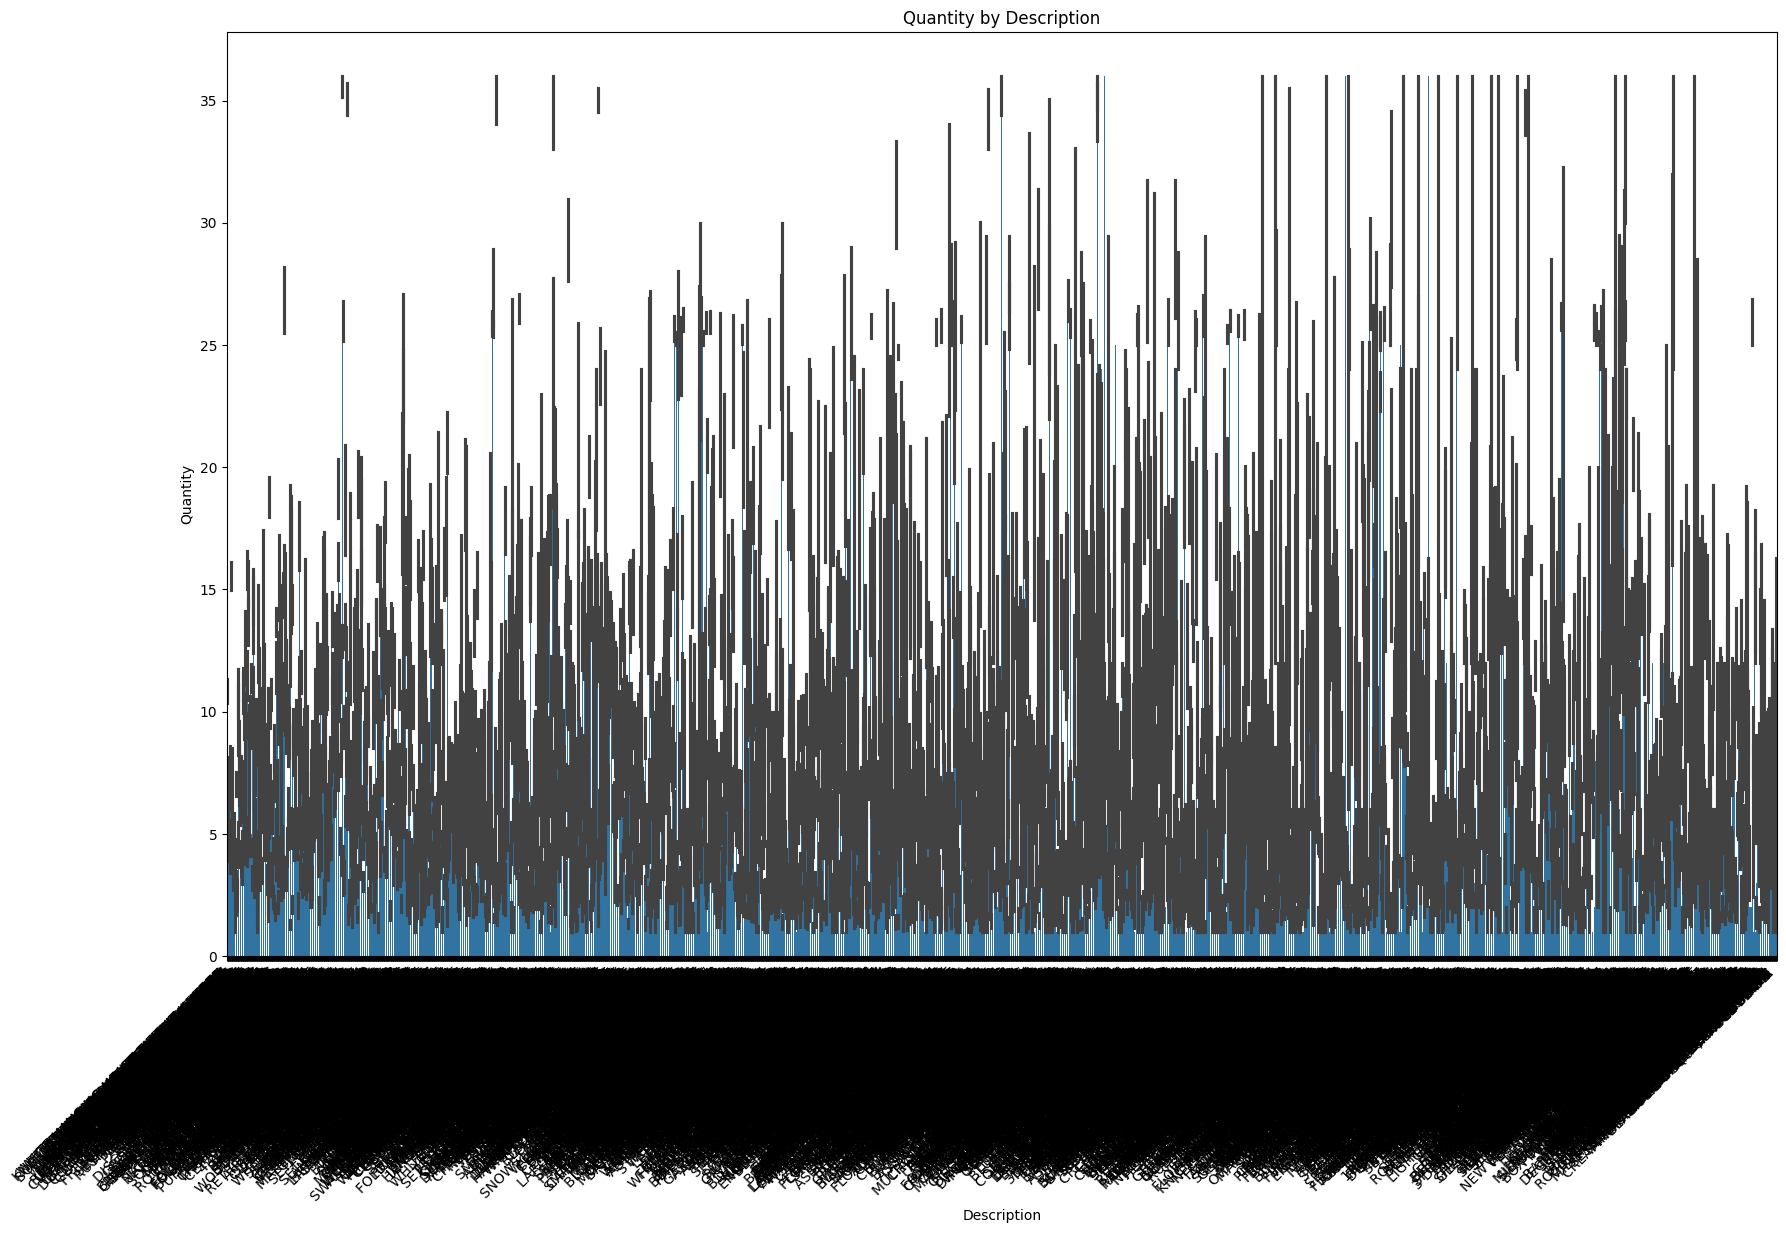

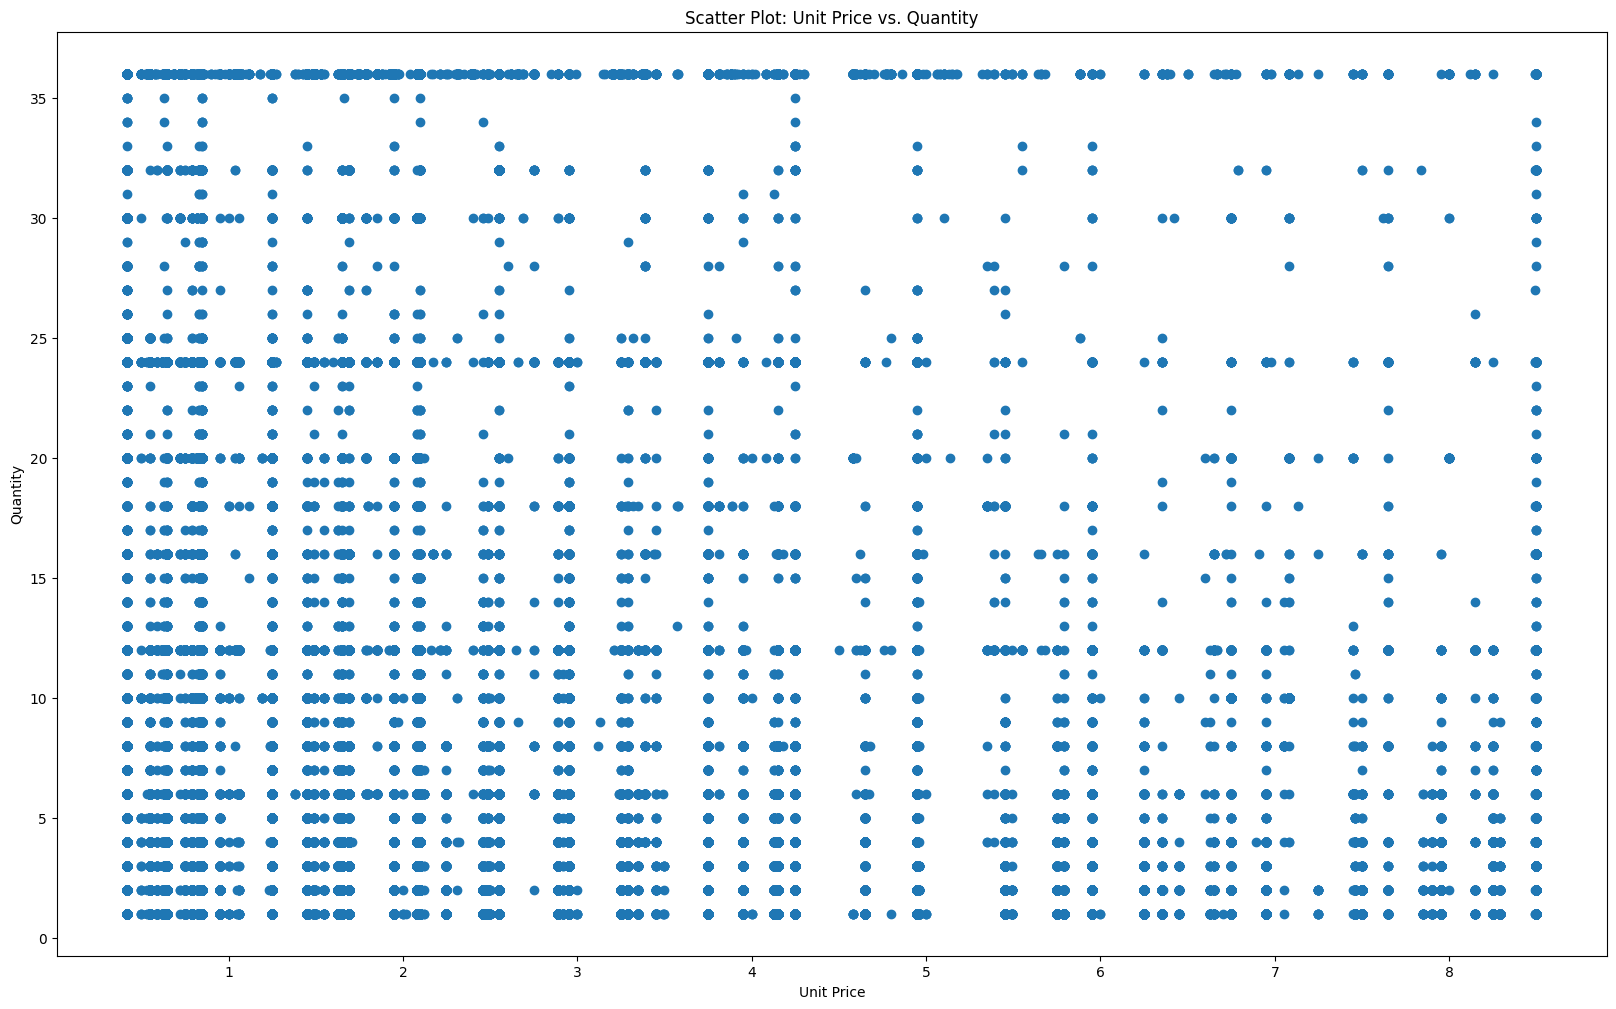

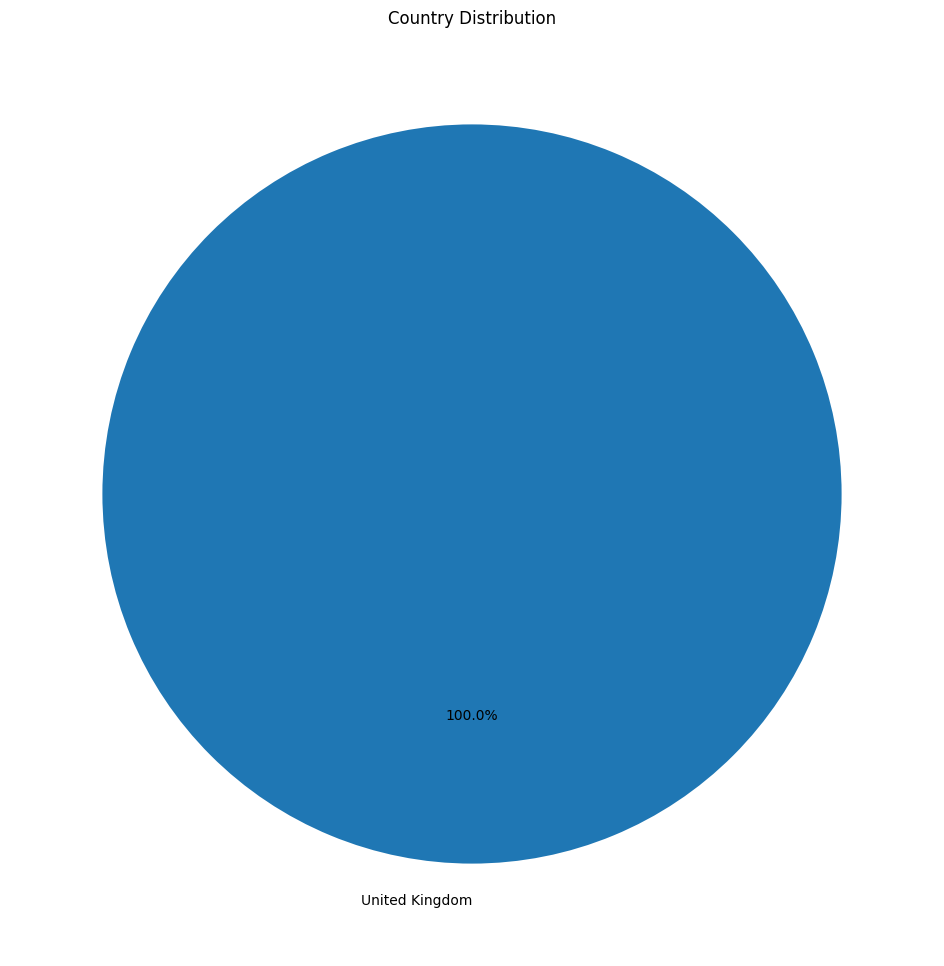

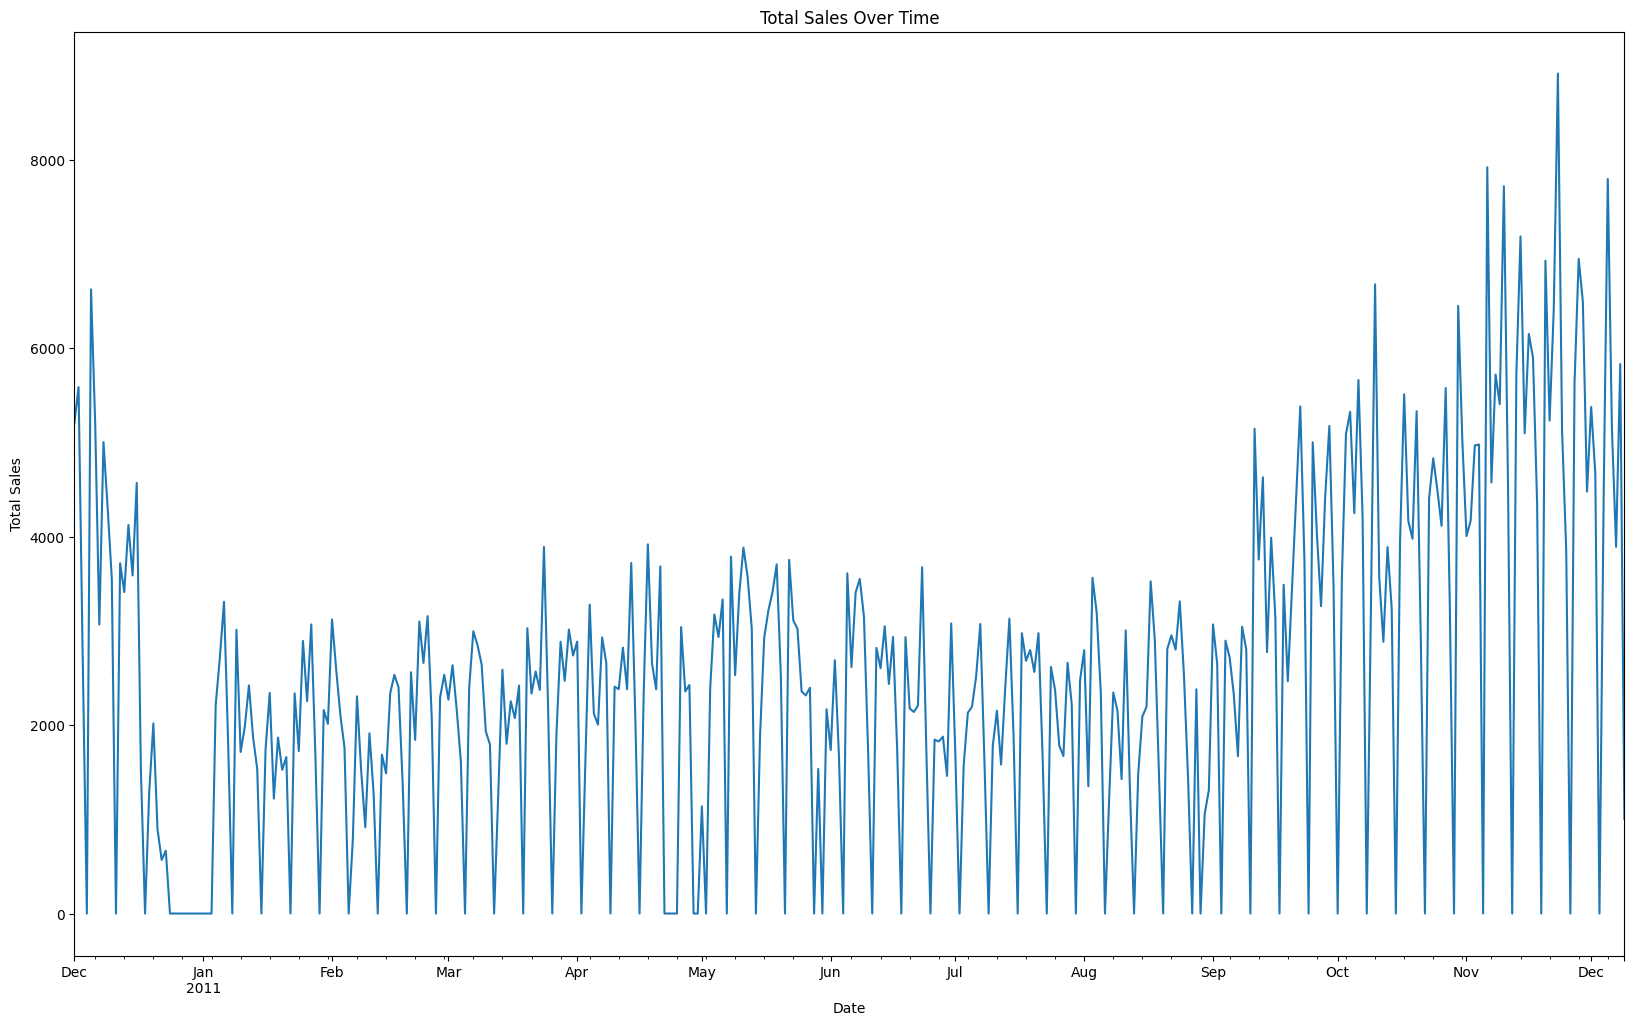

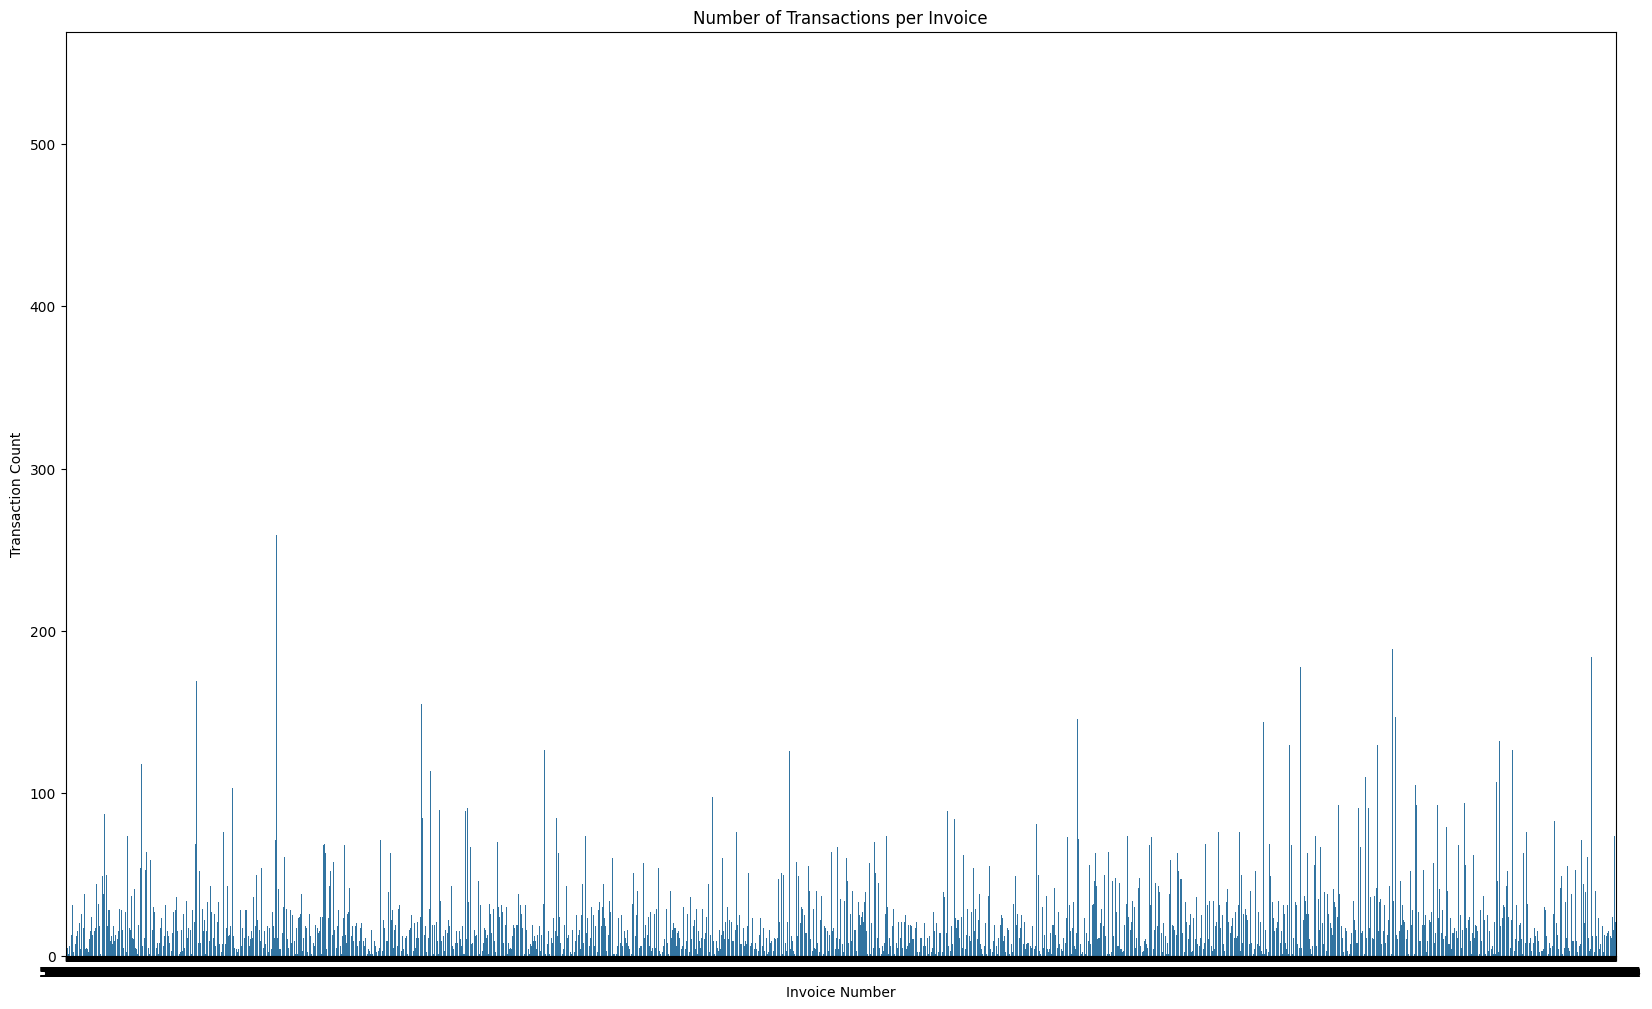

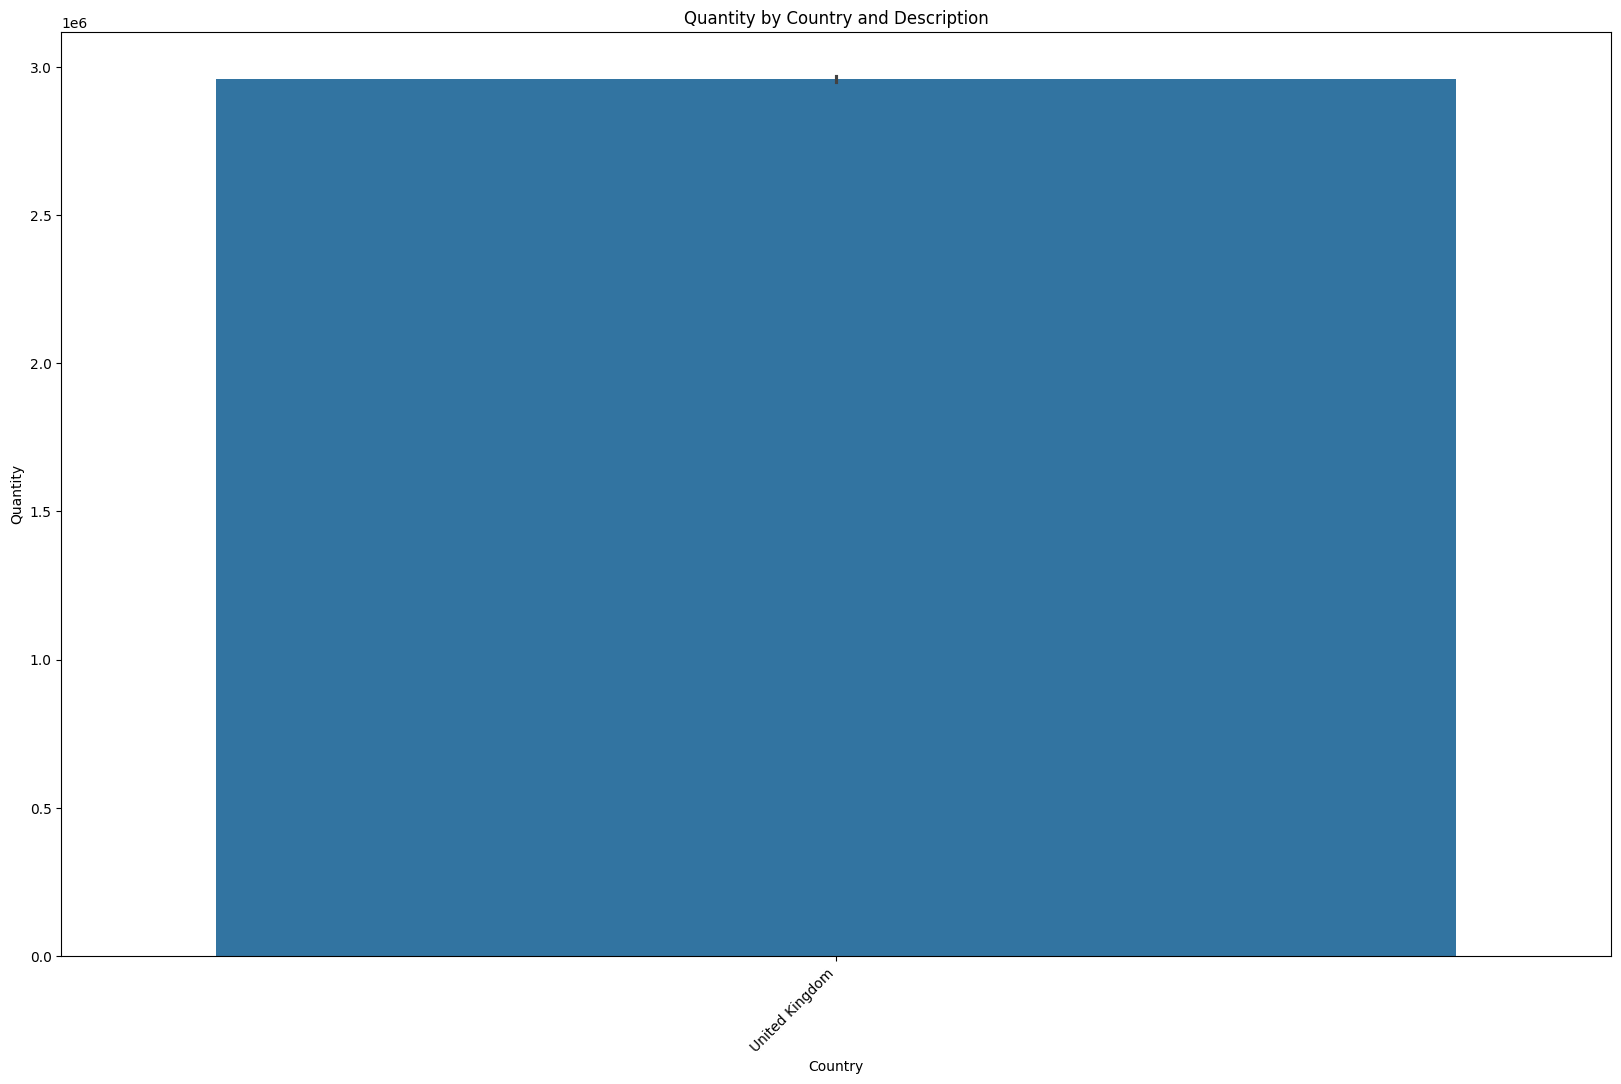

In [30]:
# Convert 'InvoiceDate' to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

plt.figure(figsize=(20, 12))

# Visualization 1: Bar chart for quantity by description
sns.barplot(x='Description', y='Quantity', data=df)
plt.title('Quantity by Description')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(20, 12))

# Visualization 2: Scatter plot for unit price and quantity
plt.scatter(df['UnitPrice'], df['Quantity'])
plt.title('Scatter Plot: Unit Price vs. Quantity')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.show()

plt.figure(figsize=(20, 12))

# Visualization 3: Pie chart for country distribution
country_counts = df['Country'].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Country Distribution')
plt.show()

plt.figure(figsize=(20, 12))

# Visualization 4: Line chart for total sales over time
df_time = df.set_index('InvoiceDate')
total_sales = df_time.resample('D').sum()['UnitPrice']
total_sales.plot(kind='line')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(20, 12))

# # Visualization 5: Box plot for quantity distribution
# sns.boxplot(x='Quantity', data=df)
# plt.title('Quantity Distribution')
# plt.show()
# plt.figure(figsize=(20, 12))


# # Visualization 6: Violin plot for unit price distribution by country
# sns.violinplot(x='Country', y='UnitPrice', data=df)
# plt.title('Unit Price Distribution by Country')
# plt.xticks(rotation=45, ha='right')
# plt.show()

# plt.figure(figsize=(20, 12))

# Visualization 7: Count plot for the number of transactions per invoice
sns.countplot(x='InvoiceNo', data=df)
plt.title('Number of Transactions per Invoice')
plt.xlabel('Invoice Number')
plt.ylabel('Transaction Count')
plt.show()

plt.figure(figsize=(20, 12))

# Visualization 8: Stacked bar chart for quantity by country and description
sns.barplot(x='Country', y='Quantity', data=df, estimator=sum)
plt.title('Quantity by Country and Description')
plt.xticks(rotation=45, ha='right')
plt.show()


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Data Processing Feature Extraction and Clipping Outliers

In [6]:
df = df[df['Quantity'] > 0 ]
df = df[df['UnitPrice'] > 0]
df = df[~df['InvoiceNo'].str.contains("C",na=False)] # drop returned items
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [7]:
df.dropna(inplace=True)

In [8]:
def find_boundaries(df, variable,q1=0.05,q2=0.95):
    # the boundaries are the quantiles
    lower_boundary = df[variable].quantile(q1)
    upper_boundary = df[variable].quantile(q2)
    return upper_boundary, lower_boundary

def capping_outliers(df,variable):
    upper_boundary,lower_boundary =  find_boundaries(df,variable)
    df[variable] = np.where(df[variable] > upper_boundary, upper_boundary,
                       np.where(df[variable] < lower_boundary, lower_boundary, df[variable]))

In [9]:
capping_outliers(df,'UnitPrice')
capping_outliers(df,'Quantity')

In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,8.868022,2011-07-10 23:41:23.511023360,2.675785,15294.423453
min,1.000000,2010-12-01 08:26:00,0.420000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,36.000000,2011-12-09 12:50:00,8.500000,18287.000000
std,9.523425,NaN,2.275053,1713.141560


In [11]:
df = df[df.Country == 'United Kingdom']

In [12]:
df['Total Price'] = df['UnitPrice'] * df['Quantity']

# RMF Scoring

In [13]:
clv = lifetimes.utils.summary_data_from_transaction_data(df,'CustomerID','InvoiceDate','Total Price')

In [14]:
clv = clv[clv['frequency']>1] # we want only customers shopped more than 2 times

In [15]:
clv

,frequency,recency,T,monetary_value
CustomerID,,,,
12747.0,10.0,367.0,369.0,375.725000
12748.0,112.0,373.0,373.0,257.314911
12749.0,3.0,210.0,213.0,999.106667
12820.0,3.0,323.0,326.0,256.573333
12823.0,4.0,222.0,296.0,252.450000
...,...,...,...,...
18263.0,2.0,227.0,252.0,467.580000
18272.0,5.0,244.0,246.0,485.688000
18273.0,2.0,255.0,257.0,71.400000


# Expected Transactions Determination

In [16]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(clv['frequency'], clv['recency'], clv['T'])

<lifetimes.BetaGeoFitter: fitted with 1738 subjects, a: 0.00, alpha: 112.07, b: 0.00, r: 2.38>

In [17]:
# Assuming 'T' is the customer's age at the time of the last observation
t = clv['T'].max()
clv['expected_purchases_all_time'] = bgf.conditional_expected_number_of_purchases_up_to_time(t, clv['frequency'], clv['recency'], clv['T'])
top_customers = clv.sort_values(by='expected_purchases_all_time', ascending=False) 


In [18]:
clv

,frequency,recency,T,monetary_value,expected_purchases_all_time
CustomerID,,,,,
12747.0,10.0,367.0,369.0,375.725000,9.600140
12748.0,112.0,373.0,373.0,257.314911,87.954230
12749.0,3.0,210.0,213.0,999.106667,6.175149
12820.0,3.0,323.0,326.0,256.573333,4.582289
12823.0,4.0,222.0,296.0,252.450000,5.833209
...,...,...,...,...,...
18263.0,2.0,227.0,252.0,467.580000,4.489148
18272.0,5.0,244.0,246.0,485.688000,7.689414
18273.0,2.0,255.0,257.0,71.400000,4.428331


# Expected Value Determination

In [19]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(clv["frequency"],
        clv["monetary_value"])

<lifetimes.GammaGammaFitter: fitted with 1738 subjects, p: 3.80, q: 0.35, v: 3.73>

In [20]:
clv['All-time']=ggf.customer_lifetime_value(bgf,
                                   clv["frequency"],
                                   clv["recency"],
                                   clv["T"],
                                   clv["monetary_value"],
                                   time=t,
                                   freq='D',
                                   discount_rate=0.01)

In [21]:
 clv.sort_values('All-time',ascending=False).head()

,frequency,recency,T,monetary_value,expected_purchases_all_time,All-time
CustomerID,,,,,,
14096.0,16.0,97.0,101.0,3012.454375,32.178296,768895.922422
18102.0,25.0,367.0,367.0,2112.843200,21.318977,355895.440317
13089.0,65.0,367.0,369.0,784.818308,52.244230,322591.905261
17511.0,27.0,371.0,373.0,1798.113704,22.593185,320821.701124
14088.0,11.0,312.0,322.0,3352.988182,11.498906,307347.087909


# Cutsomer Segemnetation

In [22]:
clv['Segment'] =  pd.qcut(clv['All-time'],4,labels = ['Inactive','Requires Attension',
                                                          'Loyal Customers','Gold Members (Premiun)'])

In [23]:
clv

,frequency,recency,T,monetary_value,expected_purchases_all_time,All-time,Segment
CustomerID,,,,,,,
12747.0,10.0,367.0,369.0,375.725000,9.600140,28824.696149,Gold Members (Premiun)
12748.0,112.0,373.0,373.0,257.314911,87.954230,177872.928841,Gold Members (Premiun)
12749.0,3.0,210.0,213.0,999.106667,6.175149,51410.957883,Gold Members (Premiun)
12820.0,3.0,323.0,326.0,256.573333,4.582289,9832.222226,Requires Attension
12823.0,4.0,222.0,296.0,252.450000,5.833209,12117.178128,Requires Attension
...,...,...,...,...,...,...,...
18263.0,2.0,227.0,252.0,467.580000,4.489148,18087.970220,Loyal Customers
18272.0,5.0,244.0,246.0,485.688000,7.689414,30391.771164,Gold Members (Premiun)
18273.0,2.0,255.0,257.0,71.400000,4.428331,2784.770729,Inactive


# Regressor Training/Evalaution for Lifetime Value Prediction

In [24]:
# Separate features and target variable for CLV prediction
clv_features = clv[['frequency', 'recency', 'T', 'monetary_value' ]]
clv_target = clv['All-time']

# Split the data into training and testing sets for CLV prediction
clv_X_train, clv_X_test, clv_y_train, clv_y_test = train_test_split(clv_features, clv_target, test_size=0.2, random_state=42)

# Train a Linear Regression model for CLV prediction
clv_model = LinearRegression()
clv_model.fit(clv_X_train, clv_y_train)

# Make predictions on the test set
clv_predictions = clv_model.predict(clv_X_test)

# Evaluate the CLV prediction model
mse = mean_squared_error(clv_y_test, clv_predictions)
print(f'Mean Squared Error for CLV Prediction: {mse}')

Mean Squared Error for CLV Prediction: 182870076.0351577


In [25]:
# Standardize features for Random Forest Regressor
scaler = StandardScaler()
clv_X_train_scaled = scaler.fit_transform(clv_X_train)
clv_X_test_scaled = scaler.transform(clv_X_test)

# Train a Random Forest Regressor for CLV prediction
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(clv_X_train_scaled, clv_y_train)

# Make predictions on the test set
clv_predictions_rf = rf_model.predict(clv_X_test_scaled)

# Evaluate the Random Forest Regressor model
mse_rf = mean_squared_error(clv_y_test, clv_predictions_rf)
print(f'Mean Squared Error for CLV Prediction (Random Forest): {mse_rf}')

Mean Squared Error for CLV Prediction (Random Forest): 25999831.832082283


# Classifier Training/Evalaution for Customer Segmentation

In [26]:
# Separate features and target variable for Segment prediction
segment_features = clv[['frequency', 'recency', 'T', 'monetary_value', 'All-time']]
segment_target = clv['Segment']

# Split the data into training and testing sets for Segment prediction
segment_X_train, segment_X_test, segment_y_train, segment_y_test = train_test_split(segment_features, segment_target, test_size=0.2, random_state=42)

# Create a pipeline for preprocessing and training the Random Forest Classifier
segment_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest Classifier for Segment prediction
segment_pipeline.fit(segment_X_train, segment_y_train)

# Make predictions on the test set
segment_predictions = segment_pipeline.predict(segment_X_test)

# Evaluate the Segment prediction model
accuracy = accuracy_score(segment_y_test, segment_predictions)
print(f'Accuracy for Segment Prediction: {accuracy}')

# Display classification report for more detailed metrics
print(classification_report(segment_y_test, segment_predictions))

Accuracy for Segment Prediction: 0.9971264367816092
                        precision    recall  f1-score   support

Gold Members (Premiun)       1.00      1.00      1.00        91
              Inactive       1.00      1.00      1.00        83
       Loyal Customers       0.99      1.00      0.99        78
    Requires Attension       1.00      0.99      0.99        96

              accuracy                           1.00       348
             macro avg       1.00      1.00      1.00       348
          weighted avg       1.00      1.00      1.00       348



# Saving Models

In [27]:
import joblib 
scaler_filename = 'standard_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f'StandardScaler object saved to {scaler_filename}')
# Save Random Forest Regressor model for CLV prediction
joblib.dump(rf_model, 'clv_rf_model.joblib')
# Save Segment prediction pipeline
joblib.dump(segment_pipeline, 'segment_pipeline.joblib')

StandardScaler object saved to standard_scaler.joblib


['segment_pipeline.joblib']

# Prediction Fucntions

In [28]:
def predict_clv(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value'])

    # Standardize the features for the Random Forest Regressor
    new_customer_features_scaled = scaler.transform(new_customer_features)

    # Predict CLV using the Random Forest Regressor
    clv_prediction = rf_model.predict(new_customer_features_scaled)[0]
    return clv_prediction

# Example usage:
new_customer_features = [58, 100, 150, 5000]  # Replace with the actual features of the new customer
predicted_clv = predict_clv(new_customer_features)

print(f'Predicted Segment: {predicted_clv}')


Predicted Segment: 554576.3359759132


In [29]:
def predict_segment(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value', 'All-time'])

    # Use the trained pipeline to standardize features and predict segment
    new_customer_segment = segment_pipeline.predict(new_customer_features)[0]
    return new_customer_segment

# Example usage:
new_customer_features = [58, 100, 150, 5000, 1000]  # Replace with the actual features of the new customer
predicted_segment = predict_segment(new_customer_features)

print(f'Predicted Segment: {predicted_segment}')


Predicted Segment: Inactive


End of Notebook